In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
project_path = "/content/drive/MyDrive/Paddy Doctor"
os.chdir(project_path)

In [ ]:
import gc
import tensorflow as tf

tf.keras.backend.clear_session()
gc.collect()

0

In [ ]:
import pickle
from data_processor import PaddyDiseaseDataProcessor
from paddy_model import PaddyDiseaseClassifierModel

In [ ]:
!cp "/content/drive/MyDrive/Paddy Doctor/paddy_disease_classification.zip" /content/

In [ ]:
!unzip -q /content/paddy_disease_classification.zip -d /content/

# **Data**

In [ ]:
paddy_data = PaddyDiseaseDataProcessor(dataset_dir="/content/paddy_disease_classification")

train_ds, val_ds, disease_encoder, variety_encoder, max_age = paddy_data.get_train_val_ds()

# **Save Encoders**

In [ ]:
encoder_path = "/content/drive/MyDrive/Paddy Doctor/trained_model/encoders.pkl"
encoders_data = {
    "disease_encoder": disease_encoder,
    "variety_encoder": variety_encoder,
    "max_age"        : max_age
}

with open(encoder_path, "wb") as f:
    pickle.dump(encoders_data, f)

print(f"Encoders and max_age saved at {encoder_path}")

Encoders and max_age saved at /content/drive/MyDrive/Paddy Doctor/trained_model/encoders.pkl


# **Model**

In [ ]:
paddy_doctor = PaddyDiseaseClassifierModel(disease_encoder, variety_encoder, max_age)

# **Training**

In [ ]:
history = paddy_doctor.train(train_ds, val_ds)
print("Training Complete")

Building new model...


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ sequential_1[0][… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease (Dense)     │ (None, 10)        │      2,570 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ variety (Dense)     │ (None, 10)        │      2,570 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,591,317 (9.89 MB)

 Trainable params: 2,194,773 (8.37 MB)

 Non-trainable params: 396,544 (1.51 MB)

Epoch 1/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - age_loss: 0.4358 - age_mae: 0.5205 - disease_accuracy: 0.2372 - disease_loss: 2.2077 - loss: 4.1949 - variety_accuracy: 0.5878 - variety_loss: 1.5501 - val_age_loss: 0.3019 - val_age_mae: 0.4431 - val_disease_accuracy: 0.1540 - val_disease_loss: 2.3110 - val_loss: 3.9125 - val_variety_accuracy: 0.6651 - val_variety_loss: 1.3020
Epoch 2/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 53s 94ms/step - age_loss: 0.2153 - age_mae: 0.3677 - disease_accuracy: 0.2471 - disease_loss: 2.1615 - loss: 3.6340 - variety_accuracy: 0.6749 - variety_loss: 1.2552 - val_age_loss: 0.2130 - val_age_mae: 0.3654 - val_disease_accuracy: 0.2399 - val_disease_loss: 2.1240 - val_loss: 3.4979 - val_variety_accuracy: 0.6790 - val_variety_loss: 1.1609
Epoch 3/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 51s 93ms/step - age_loss: 0.1778 - age_mae: 0.3368 - disease_accuracy: 0.2641 - disease_loss: 2.0980 - loss: 3.4522 - variety_accuracy: 0.6824 - variety_loss: 1.1755 - val_age_loss: 0.1

In [ ]:
import os
model_save_path = "/content/drive/MyDrive/Paddy Doctor/trained_model/paddy_doctor.h5"
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
paddy_doctor.model.save(model_save_path)

print(f"✅ Model successfully saved to: {model_save_path}")

✅ Model successfully saved to: /content/drive/MyDrive/Paddy Doctor/trained_model/paddy_doctor.h5


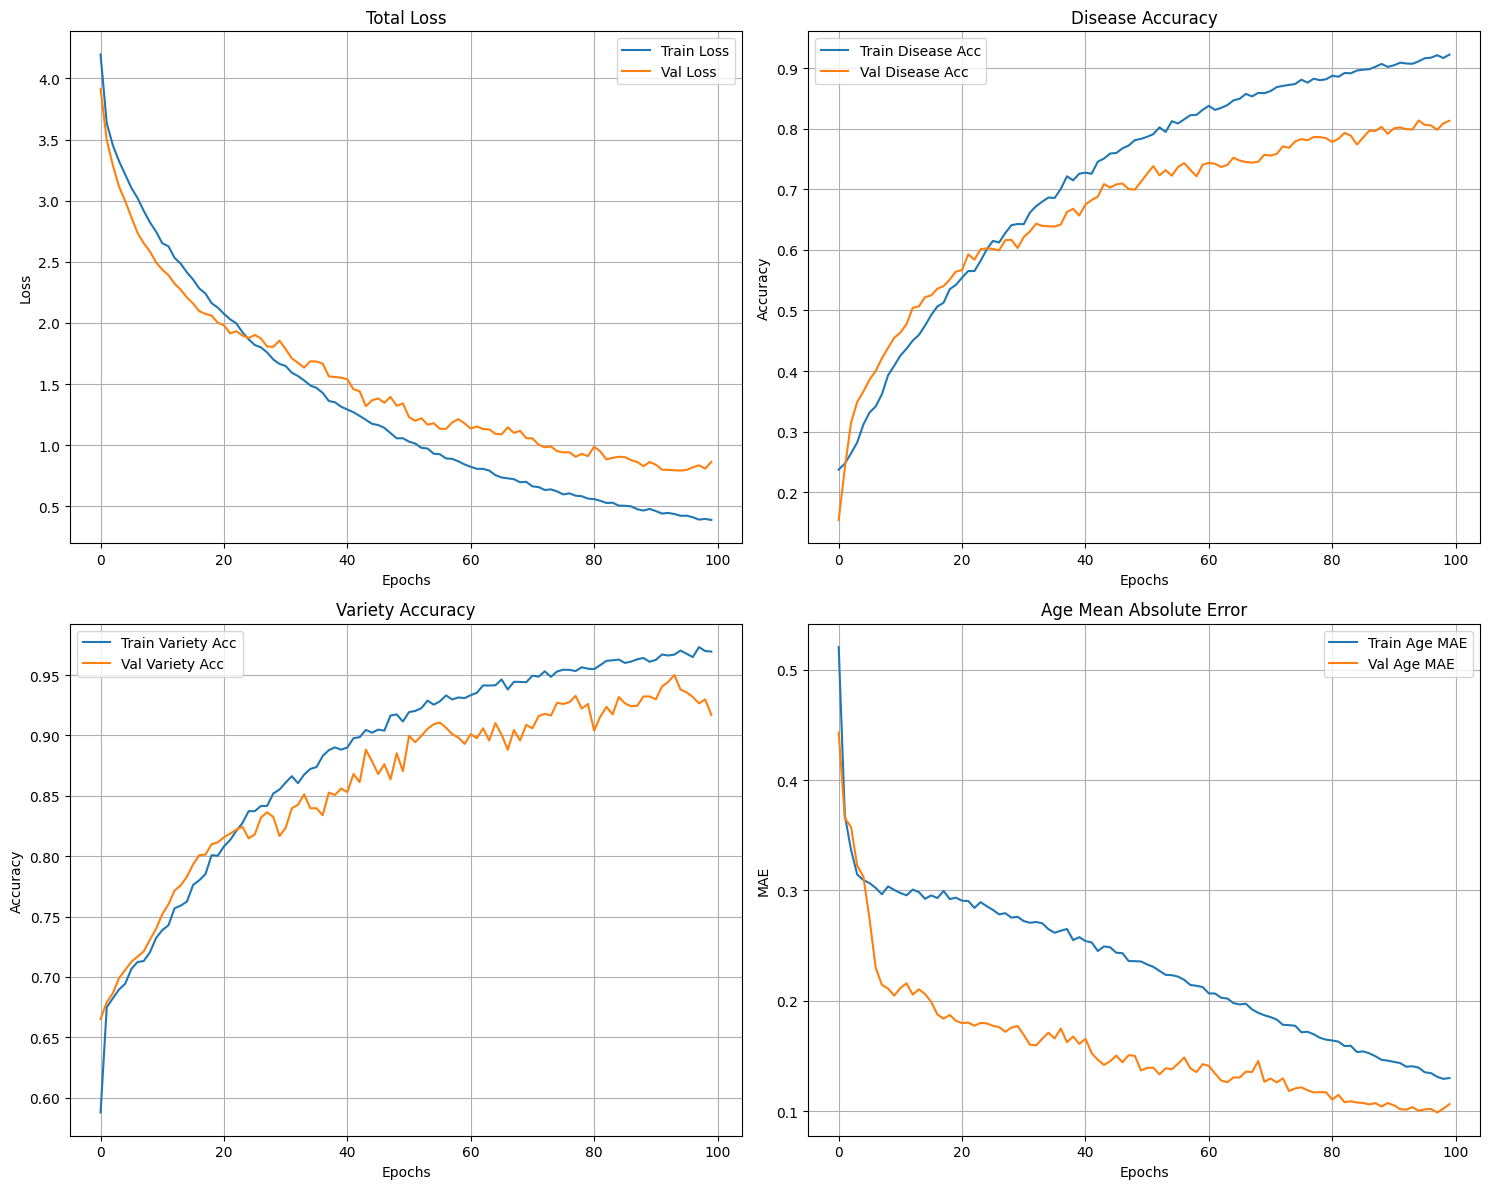

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    axes[0, 0].plot(history.history['loss'], label='Train Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(history.history['disease_accuracy'], label='Train Disease Acc')
    axes[0, 1].plot(history.history['val_disease_accuracy'], label='Val Disease Acc')
    axes[0, 1].set_title('Disease Accuracy')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[1, 0].plot(history.history['variety_accuracy'], label='Train Variety Acc')
    axes[1, 0].plot(history.history['val_variety_accuracy'], label='Val Variety Acc')
    axes[1, 0].set_title('Variety Accuracy')
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(history.history['age_mae'], label='Train Age MAE')
    axes[1, 1].plot(history.history['val_age_mae'], label='Val Age MAE')
    axes[1, 1].set_title('Age Mean Absolute Error')
    axes[1, 1].set_xlabel('Epochs')
    axes[1, 1].set_ylabel('MAE')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)